In [1]:
import pandas as pd


In [2]:
customer_df = pd.read_csv("customer_df.csv")

In [3]:
customer_df.columns

Index(['Unnamed: 0', 'customer_unique_id', 'customer_state', 'customer_city',
       'total_orders', 'total_spend', 'avg_order_value', 'avg_review_score',
       'recency_days', 'purchase_frequency', 'avg_days_between_orders',
       'churn'],
      dtype='object')

In [4]:
customer_df.head()

,Unnamed: 0,customer_unique_id,customer_state,customer_city,total_orders,total_spend,avg_order_value,avg_review_score,recency_days,purchase_frequency,avg_days_between_orders,churn
0,0,0000366f3b9a7992bf8c76cfdf3221e2,SP,cajamar,1,141.90,141.90,5.0,116,30.0,0.0,1
1,1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,osasco,1,27.19,27.19,4.0,119,30.0,0.0,1
2,2,0000f46a3911fa3c0805444483337064,SC,sao jose,1,86.22,86.22,3.0,542,30.0,0.0,1
3,3,0000f6ccb0745a6a4b88665a16c9f078,PA,belem,1,43.62,43.62,4.0,326,30.0,0.0,1
4,4,0004aac84e0df4da2b147fca70cf8255,SP,sorocaba,1,196.89,196.89,5.0,293,30.0,0.0,1


In [5]:
customer_df = customer_df.drop(columns = 'Unnamed: 0') 

In [6]:
customer_df.columns.to_list 

<bound method IndexOpsMixin.tolist of Index(['customer_unique_id', 'customer_state', 'customer_city', 'total_orders',
       'total_spend', 'avg_order_value', 'avg_review_score', 'recency_days',
       'purchase_frequency', 'avg_days_between_orders', 'churn'],
      dtype='object')>

In [7]:
customer_df.head()

,customer_unique_id,customer_state,customer_city,total_orders,total_spend,avg_order_value,avg_review_score,recency_days,purchase_frequency,avg_days_between_orders,churn
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,cajamar,1,141.90,141.90,5.0,116,30.0,0.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,osasco,1,27.19,27.19,4.0,119,30.0,0.0,1
2,0000f46a3911fa3c0805444483337064,SC,sao jose,1,86.22,86.22,3.0,542,30.0,0.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,PA,belem,1,43.62,43.62,4.0,326,30.0,0.0,1
4,0004aac84e0df4da2b147fca70cf8255,SP,sorocaba,1,196.89,196.89,5.0,293,30.0,0.0,1


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt



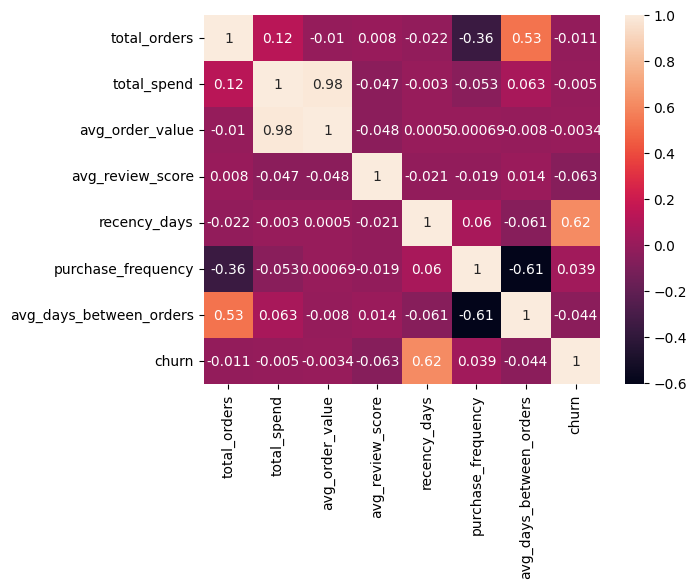

In [9]:
sns.heatmap(customer_df.corr(numeric_only=True),annot=True)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import shap
import joblib

import warnings
warnings.filterwarnings("ignore")

c:\Users\Samyak\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
df = customer_df.copy()

In [12]:
df

,customer_unique_id,customer_state,customer_city,total_orders,total_spend,avg_order_value,avg_review_score,recency_days,purchase_frequency,avg_days_between_orders,churn
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,cajamar,1,141.90,141.90,5.0,116,30.0,0.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,osasco,1,27.19,27.19,4.0,119,30.0,0.0,1
2,0000f46a3911fa3c0805444483337064,SC,sao jose,1,86.22,86.22,3.0,542,30.0,0.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,PA,belem,1,43.62,43.62,4.0,326,30.0,0.0,1
4,0004aac84e0df4da2b147fca70cf8255,SP,sorocaba,1,196.89,196.89,5.0,293,30.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
95415,fffcf5a5ff07b0908bd4e2dbc735a684,PE,sanharo,1,2067.42,2067.42,5.0,452,30.0,0.0,1
95416,fffea47cd6d3cc0a88bd621562a9d061,BA,feira de santana,1,84.58,84.58,4.0,267,30.0,0.0,1
95417,ffff371b4d645b6ecea244b27531430a,MT,sinop,1,112.46,112.46,5.0,573,30.0,0.0,1
95418,ffff5962728ec6157033ef9805bacc48,ES,bom jesus do norte,1,133.69,133.69,5.0,124,30.0,0.0,1


In [13]:
df = df.drop_duplicates(
    subset=["customer_unique_id"],
    keep="first"
)

print(df.isnull().sum())

customer_unique_id         0
customer_state             0
customer_city              0
total_orders               0
total_spend                0
avg_order_value            0
avg_review_score           0
recency_days               0
purchase_frequency         0
avg_days_between_orders    0
churn                      0
dtype: int64


In [14]:
categorical_columns = [
    "customer_state",
    "customer_city"
]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

In [15]:
numerical_columns = [
    "total_orders",
    "total_spend",
    "avg_order_value",
    "avg_review_score",
    "recency_days",
    "purchase_frequency",
    "avg_days_between_orders"
]

for col in numerical_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    df[col] = df[col].fillna(
        df[col].median()
    )

In [16]:
df["churn"] = (
    df["recency_days"] > 90
).astype(int)

In [17]:
print(
    df["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn
1    81.2
0    18.8
Name: proportion, dtype: float64


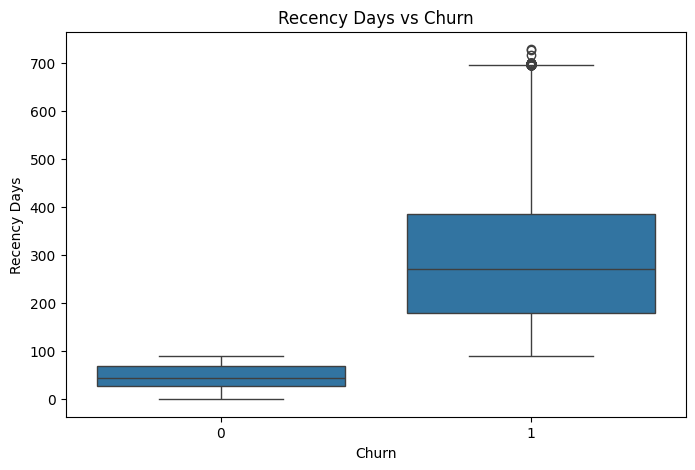

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churn",
    y="recency_days"
)

plt.title("Recency Days vs Churn")
plt.xlabel("Churn")
plt.ylabel("Recency Days")

plt.show()

In [19]:
feature_columns = [
    "customer_state",
    "customer_city",
    "total_orders",
    "total_spend",
    "avg_order_value",
    "avg_review_score",
    "recency_days",
    "purchase_frequency",
    "avg_days_between_orders"
]

In [20]:
target_column = "churn"

In [21]:
X = df[feature_columns].copy()

y = df[target_column].copy()

In [22]:
X

,customer_state,customer_city,total_orders,total_spend,avg_order_value,avg_review_score,recency_days,purchase_frequency,avg_days_between_orders
0,SP,cajamar,1,141.90,141.90,5.0,116,30.0,0.0
1,SP,osasco,1,27.19,27.19,4.0,119,30.0,0.0
2,SC,sao jose,1,86.22,86.22,3.0,542,30.0,0.0
3,PA,belem,1,43.62,43.62,4.0,326,30.0,0.0
4,SP,sorocaba,1,196.89,196.89,5.0,293,30.0,0.0
...,...,...,...,...,...,...,...,...,...
95415,PE,sanharo,1,2067.42,2067.42,5.0,452,30.0,0.0
95416,BA,feira de santana,1,84.58,84.58,4.0,267,30.0,0.0
95417,MT,sinop,1,112.46,112.46,5.0,573,30.0,0.0
95418,ES,bom jesus do norte,1,133.69,133.69,5.0,124,30.0,0.0


In [23]:
y

0        1
1        1
2        1
3        1
4        1
        ..
95415    1
95416    1
95417    1
95418    1
95419    1
Name: churn, Length: 95420, dtype: int64

In [24]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (95420, 9)
y shape: (95420,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)


In [26]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 76336
Testing samples: 19084

Training target distribution:
churn
1    61985
0    14351
Name: count, dtype: int64

Testing target distribution:
churn
1    15496
0     3588
Name: count, dtype: int64


In [27]:
categorical_features = [
    "customer_state",
    "customer_city"
]


numerical_features = [
    "total_orders",
    "total_spend",
    "avg_order_value",
    "avg_review_score",
    "recency_days",
    "purchase_frequency",
    "avg_days_between_orders"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)


# Logistic Regression Model

In [28]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [29]:
logistic_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(
    X_test
)[:, 1]

# Random Forest Model

In [31]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)



In [32]:
random_forest_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
y_pred_rf = random_forest_model.predict(
    X_test
)

y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]

# Gradient Boosting Model

In [34]:
gradient_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)



In [35]:
gradient_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
y_pred_gb = gradient_model.predict(
    X_test
)

y_prob_gb = gradient_model.predict_proba(
    X_test
)[:, 1]

# Model Evaluation

In [58]:
import numpy as np
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_probability
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    try:
        roc_auc = roc_auc_score(
            y_true,
            y_probability
        )
    except ValueError:
        roc_auc = np.nan

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }


# Comparing the Models

In [38]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        y_prob_lr
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        y_pred_gb,
        y_prob_gb
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.997642,0.999741,0.997354,0.998546,0.999982
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
2,Gradient Boosting,1.000000,1.000000,1.000000,1.000000,1.000000


Best Model will be selected according to the F1 score

In [39]:
best_model_name = (
    results_df
    .sort_values(
        by="F1 Score",
        ascending=False
    )
    .iloc[0]["Model"]
)

print(
    "Best Model:",
    best_model_name
)

Best Model: Random Forest


In [40]:
if best_model_name == "Logistic Regression":

    best_model = logistic_model

    best_predictions = y_pred_lr

    best_probabilities = y_prob_lr


elif best_model_name == "Random Forest":

    best_model = random_forest_model

    best_predictions = y_pred_rf

    best_probabilities = y_prob_rf


else:

    best_model = gradient_model

    best_predictions = y_pred_gb

    best_probabilities = y_prob_gb

# Classification Report

In [41]:
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Not Churned",
            "Churned"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Not Churned       1.00      1.00      1.00      3588
     Churned       1.00      1.00      1.00     15496

    accuracy                           1.00     19084
   macro avg       1.00      1.00      1.00     19084
weighted avg       1.00      1.00      1.00     19084



# Confusion Matrix

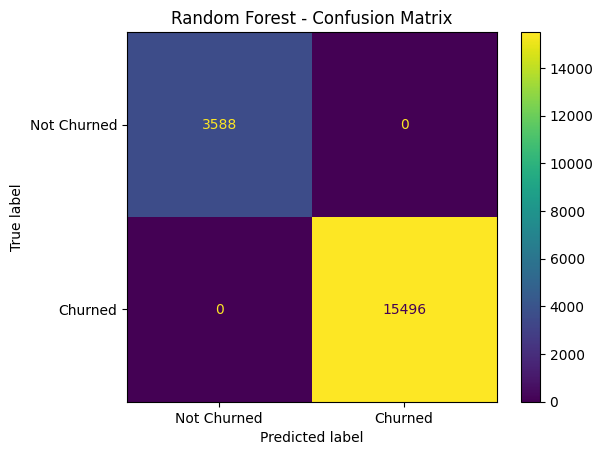

In [42]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Churned",
        "Churned"
    ]
)

disp.plot()

plt.title(
    f"{best_model_name} - Confusion Matrix"
)

plt.show()

# Explainable AI

In [43]:
rf_preprocessor = random_forest_model.named_steps[
    "preprocessor"
]

rf_classifier = random_forest_model.named_steps[
    "classifier"
]

In [44]:
X_test_transformed = rf_preprocessor.transform(
    X_test
)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_test_transformed = X_test_transformed.astype(float)

In [45]:
feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

In [46]:
explainer = shap.TreeExplainer(
    rf_classifier
)

In [47]:
shap_values = explainer.shap_values(
    X_test_transformed
)

In [48]:
if isinstance(shap_values, list):

    shap_values_plot = shap_values[1]

else:

    shap_values_plot = shap_values

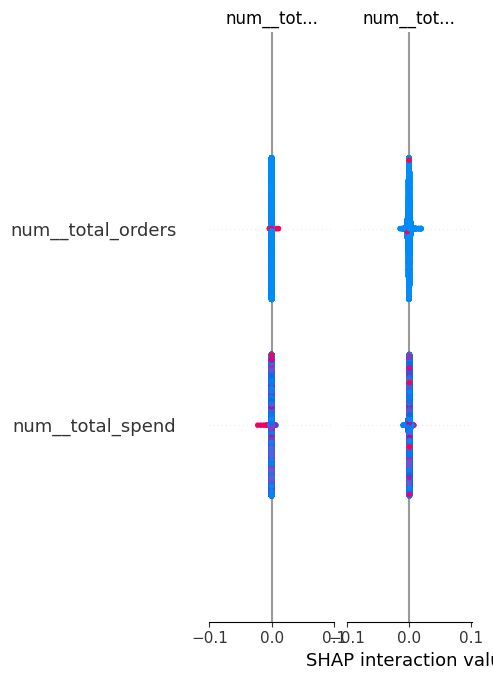

In [49]:
shap.summary_plot(
    shap_values_plot,
    X_test_transformed,
    feature_names=feature_names
)

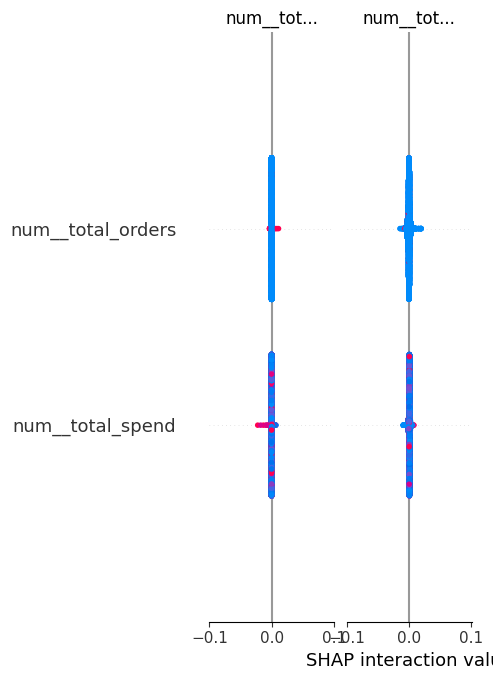

In [50]:
shap.summary_plot(
    shap_values_plot,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [51]:
import os

os.makedirs(
    "models/customer",
    exist_ok=True
)

os.makedirs(
    "models/customer/shap",
    exist_ok=True
)

In [52]:
joblib.dump(
    best_model,
    "models/customer/customer_churn_model.pkl"
)

['models/customer/customer_churn_model.pkl']

In [53]:
results_df.to_csv(
    "models/customer/model_evaluation.csv",
    index=False
)

In [54]:
plt.figure()

shap.summary_plot(
    shap_values_plot,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    "models/customer/shap/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

<Figure size 640x480 with 0 Axes>

In [55]:
plt.figure()

shap.summary_plot(
    shap_values_plot,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "models/customer/shap/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

<Figure size 640x480 with 0 Axes>

In [56]:
import os
import joblib

# Create folder
os.makedirs("models/customer", exist_ok=True)

# Features used by the model
feature_columns = [
    "customer_state",
    "customer_city",
    "total_orders",
    "total_spend",
    "avg_order_value",
    "avg_review_score",
    "recency_days",
    "purchase_frequency",
    "avg_days_between_orders"
]

# Save the trained model
joblib.dump(
    best_model,
    "models/customer/customer_churn_model.pkl"
)

# Save the feature list
joblib.dump(
    feature_columns,
    "models/customer/customer_features.pkl"
)

print("Model saved successfully.")
print("Feature list saved successfully.")

Model saved successfully.
Feature list saved successfully.
